# _Machine Learning Operations - MLOps_

_Bu derstte eğitilen modelleri kaydedip bir uygulama içerisinde kullanmayı öğreneceğiz._

### _İmport_

In [1]:
import pandas as pd  
import seaborn as sns  
from sklearn.linear_model import LinearRegression  
import pickle  

# Gerekli kütüphaneleri içe aktarıyoruz  
# pandas → veri analizi ve DataFrame işlemleri için  
# seaborn → veri görselleştirme (grafikler) için  
# LinearRegression → doğrusal regresyon modeli kurmak için  
# pickle → modeli kaydetmek ve daha sonra yeniden yüklemek için kullanılır

### _Eda - Veri Görselleştirmesi_

In [2]:
df = pd.read_csv('hiring.csv')  

# 'hiring.csv' dosyasını okuyarak veriyi pandas DataFrame’e aktarıyoruz  
# Bu veri genellikle işe alım (hiring) ile ilgili bilgiler içerir

In [3]:
df.head()  

# Veri setinin ilk 5 satırını görüntülüyoruz  
# Bu sayede sütun adlarını, veri tiplerini ve genel yapıyı hızlıca gözlemleyebiliriz

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


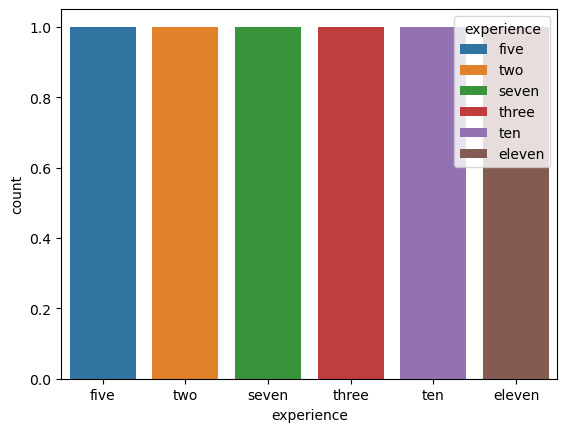

In [4]:
sns.countplot(x=df['experience'], hue=df['experience']);  

# 'experience' sütunundaki değerlerin dağılımını görselleştiriyoruz  
# countplot, her deneyim seviyesinin kaç kez geçtiğini gösterir  
# hue=df['experience'] ifadesi, her kategoriyi kendi rengiyle vurgular

In [5]:
df.shape  

# Veri setinin satır ve sütun sayısını gösterir  
# Çıktı, (satır_sayısı, sütun_sayısı) formatında olur

(8, 4)

In [6]:
d = {'two': 2, 'three': 3, 'five': 5, 'seven': 7, 'eight': 8, 'ten': 10, 'eleven': 11}  

# Sayıların yazıyla belirtilmiş hallerini sayısal değerlere eşleyen bir sözlük oluşturuyoruz  
# Bu sözlük, veri setindeki metinsel deneyim ifadelerini (örneğin 'two') sayıya çevirmek için kullanılabilir

In [7]:
df['experience'] = df['experience'].map(d)  

# 'experience' sütunundaki metinsel değerleri (örneğin 'two', 'five') sayısal değerlere dönüştürüyoruz  
# map() fonksiyonu, her bir değeri sözlükteki karşılığıyla eşleştirir

In [8]:
df['experience'] = df['experience'].fillna(0)  

# 'experience' sütunundaki eksik (NaN) değerleri 0 ile dolduruyoruz  
# Böylece model eğitiminde eksik veri kaynaklı hataların önüne geçilir

In [9]:
df  

# Güncellenmiş veri setini görüntülüyoruz  
# Artık 'experience' sütunundaki tüm değerler sayısal hale geldi ve eksik veriler 0 ile dolduruldu

,experience,test_score,interview_score,salary
0,0.0,8.0,9,50000
1,0.0,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000
5,3.0,7.0,10,62000
6,10.0,NaN,7,72000
7,11.0,7.0,8,80000


In [10]:
df['test_score'] = df['test_score'].fillna(df['test_score'].mean())  

# 'test_score' sütunundaki eksik değerleri, sütunun ortalama testi skoru ile dolduruyoruz  
# Bu yöntem, eksik verilerin model performansını olumsuz etkilemesini önler

### _Modelling_

In [11]:
x = df.drop('salary', axis=1)  
y = df[['salary']]  

# Bağımsız değişkenler (girdi özellikleri) olarak 'salary' dışındaki tüm sütunları seçiyoruz  
# Bağımlı değişken (tahmin edilmek istenen hedef) olarak 'salary' sütununu belirliyoruz

In [12]:
# Geçmişte modelin başarı oranı tatmin edici olduğu için veriyi yeniden train_test_split ile bölmeyeceğiz  
# Yani mevcut tüm veriyi doğrudan modelin eğitimi için kullanacağız

#### _Linear Regression_

In [13]:
lr = LinearRegression()  

# Lineer regresyon modelini oluşturuyoruz  
# Bu model, girdi değişkenleri ile maaş (salary) arasındaki doğrusal ilişkiyi öğrenmek için kullanılacak

In [14]:
model = lr.fit(x, y)  

# Lineer regresyon modelini tüm veri üzerinde eğitiyoruz  
# fit() metodu, girdiler (x) ile hedef (y) arasındaki en uygun doğrusal ilişkiyi öğrenir

In [15]:
pickle.dump(model, open('maas.pkl', 'wb'))  

# Eğitilmiş modeli 'maas.pkl' adlı dosyaya kaydediyoruz  
# 'wb' modu (write binary), dosyayı ikili formatta yazmak için kullanılır  
# Böylece modeli daha sonra yeniden yükleyip kullanabiliriz

#### _Kaydettiğimiz Modeli Yükleyelim_

In [16]:
kmodel = pickle.load(open('maas.pkl', 'rb'))  

# Daha önce kaydettiğimiz modeli 'maas.pkl' dosyasından geri yüklüyoruz  
# 'rb' modu (read binary), dosyayı ikili formatta okur  
# Artık kmodel değişkeni, eğitilmiş lineer regresyon modelini içeriyor

In [17]:
kmodel.predict([[2, 9, 9]])[0][0]  

# Yüklenen modeli kullanarak yeni bir tahmin yapıyoruz  
# Girdi: experience = 2, test_score = 9, interview_score = 9  
# predict() metodu tahmini maaşı döndürür  
# [0][0], tahmin sonucundaki tek değeri (sayısal maaş tahmini) alır

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(59881.81850176191)

_Bu derstte eğitilen modelleri kaydedip bir uygulama içerisinde kullanmayı öğrendik._